In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import csv
import geopandas as gpd
import pylab 
import scipy.stats as stats
from scipy import ndimage
import gmaps 
import gmaps.datasets 
from datetime import datetime

%matplotlib inline

In [3]:
# Set the Filepath
points_file_path = "data/project/points/Medfly_points.shp"
plots_file_path = "data/project/plots/Medfly_plots.shp"
centroids_file_path = "data/project/centroids/Hula_centroids.shp"

# Read the Data
points = gpd.read_file(points_file_path)
plots = gpd.read_file(plots_file_path)
hula_centroids = gpd.read_file(centroids_file_path)

In [50]:
plots[plots['Grower'] == 'Avney Eitan']

,Plot,Crop,Start,End,Grower,Group,Region,"Area, ha",Season yea,geometry,date,year,month,day
12,1,Peach,1/1/18 0:00,None,Avney Eitan,None,Golan,2.75,None,"POLYGON ((35.7526844430001 32.823055353, 35.75...",2018-01-01,2018.0,1.0,1.0
255,101,Peach and nectarine,1/1/13 0:00,None,Avney Eitan,None,Golan,1.18,None,"POLYGON ((35.75728874900005 32.81741574400007,...",2013-01-01,2013.0,1.0,1.0
385,102,Peach and nectarine,1/1/13 0:00,None,Avney Eitan,None,Golan,1.19,None,"POLYGON ((35.75834457300004 32.81631800300005,...",2013-01-01,2013.0,1.0,1.0
526,103,Nectarine,1/1/13 0:00,None,Avney Eitan,None,Golan,1.18,None,"POLYGON ((35.758851027 32.815719028, 35.759044...",2013-01-01,2013.0,1.0,1.0
633,104,Unrooted,1/2/18 0:00,None,Avney Eitan,None,Golan,1.13,None,"POLYGON ((35.7597597700001 32.8148939270001, 3...",2018-02-01,2018.0,2.0,1.0
638,104,Nectarine,2/2/17 0:00,31/01/2018 00:00,Avney Eitan,None,Golan,1.13,None,"POLYGON ((35.7597597700001 32.8148939270001, 3...",2017-02-02,2017.0,2.0,2.0
642,104,Unrooted,2/2/16 0:00,1/2/17 0:00,Avney Eitan,None,Golan,1.13,None,"POLYGON ((35.7597597700001 32.8148939270001, 3...",2016-02-02,2016.0,2.0,2.0
652,104,Pears,1/1/13 0:00,1/2/16 0:00,Avney Eitan,None,Golan,1.13,None,"POLYGON ((35.7597597700001 32.8148939270001, 3...",2013-01-01,2013.0,1.0,1.0
1193,11,Peach and nectarine,1/1/13 0:00,None,Avney Eitan,None,Golan,1.13,None,"POLYGON ((35.75114744100006 32.82025798300003,...",2013-01-01,2013.0,1.0,1.0
1227,110,Peach,1/1/18 0:00,None,Avney Eitan,None,Golan,0.45,None,"POLYGON ((35.7589128120001 32.817164296, 35.75...",2018-01-01,2018.0,1.0,1.0


In [46]:
points.head()

,Project,Region,Plot,Date,Crop,Measuremen,Data,Lat,Lon,geometry,date,year,month,day
0,Hula,Metula low,None,15/06/2017,Plum,Medfly infection,0,33.249242,35.586865,POINT (35.5868654 33.2492421),2017-06-15,2017,6,15
1,Hula,Metula low,1807,15/06/2017,Peach,Medfly infection,0,33.244073,35.612303,POINT (35.6123033 33.2440733),2017-06-15,2017,6,15
2,Hula,Metula low,872,15/06/2017,Pears,Medfly infection,0,33.249243,35.586867,POINT (35.5868673 33.2492429),2017-06-15,2017,6,15
3,Hula,Metula low,857,15/06/2017,Pears,Medfly infection,0,33.249243,35.586867,POINT (35.5868674 33.2492429),2017-06-15,2017,6,15
4,Hula,Metula low,1788,15/06/2017,Nectarine,Medfly infection,0,NaN,NaN,None,2017-06-15,2017,6,15


In [47]:
hula_centroids.head()

,project,grower,plot_name,report_dat,crop,pest,data,latitude,longitude,plot_latit,plot_longi,geometry
0,Hula,Avney Eitan,Avney Eitan_103,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NULL,NULL,32.816108,35.759777,POINT (35.759777 32.816108)
1,Hula,Avney Eitan,Avney Eitan_117,6/14/17 0:00,Plum,Medfly Trap Male,0,NULL,NULL,32.814104,35.762524,POINT (35.762524 32.814104)
2,Hula,Avney Eitan,Avney Eitan_146,6/14/17 0:00,Pears,Medfly Trap Male,0,NULL,NULL,32.815617,35.765191,POINT (35.765191 32.815617)
3,Hula,Avney Eitan,Avney Eitan_167,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NULL,NULL,32.814700,35.768080,POINT (35.76808 32.8147)
4,Hula,Avney Eitan,Avney Eitan_204,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NULL,NULL,32.801553,35.781607,POINT (35.781607 32.801553)


In [36]:
points['Project'].value_counts()

Hula           469907
Tali Grapes     39139
Zifit Darom      9467
Sela               63
Yaham              54
Zemach             15
Name: Project, dtype: int64

In [35]:
points[points['Crop'] == 'Plum']

,Project,Region,Plot,Date,Crop,Measuremen,Data,Lat,Lon,geometry,date,year,month,day
0,Hula,Metula low,None,15/06/2017,Plum,Medfly infection,0,33.249242,35.586865,POINT (35.5868654 33.2492421),2017-06-15,2017,6,15
46,Hula,Metula Margaliyot,318,15/06/2017,Plum,Medfly infection,0,NaN,NaN,None,2017-06-15,2017,6,15
57,Hula,Metula Margaliyot,388,15/06/2017,Plum,Medfly infection,0,NaN,NaN,None,2017-06-15,2017,6,15
59,Hula,Yesud HaMa'ala,1625,15/06/2017,Plum,Medfly infection,0,33.061313,35.613820,POINT (35.6138196 33.0613132),2017-06-15,2017,6,15
69,Hula,Yesud HaMa'ala,102,15/06/2017,Plum,Medfly infection,0,33.054592,35.609035,POINT (35.6090346 33.0545925),2017-06-15,2017,6,15
71,Hula,Yesud HaMa'ala,1629,15/06/2017,Plum,Medfly infection,0,33.066500,35.610363,POINT (35.6103633 33.0665),2017-06-15,2017,6,15
80,Hula,Yesud HaMa'ala,295,15/06/2017,Plum,Medfly infection,0,33.075200,35.585033,POINT (35.5850333 33.0752),2017-06-15,2017,6,15
81,Hula,Yesud HaMa'ala,495,15/06/2017,Plum,Medfly infection,0,33.075200,35.585033,POINT (35.5850333 33.0752),2017-06-15,2017,6,15
84,Hula,Yesud HaMa'ala,645,15/06/2017,Plum,Medfly infection,0,33.075260,35.585007,POINT (35.5850067 33.07526),2017-06-15,2017,6,15
86,Hula,Metula low,502,15/06/2017,Plum,Medfly infection,0,NaN,NaN,None,2017-06-15,2017,6,15


In [44]:
hula_centroids[hula_centroids['plot_name']]

AttributeError: 'Series' object has no attribute 'contains'

In [5]:
def convert_points(date):
    if date is None:
        return
    if len(date) == 10:
        return datetime.strptime(date, '%d/%m/%Y')
    else:
        return datetime.strptime(date, '%d/%m/%y %H:%M')

In [6]:
datetimes = points['Date'].apply(convert_points)
points['date'] = datetimes
points.head()

,Project,Region,Plot,Date,Crop,Measuremen,Data,Lat,Lon,geometry,date
0,Hula,Metula low,None,15/06/2017,Plum,Medfly infection,0,33.249242,35.586865,POINT (35.5868654 33.2492421),2017-06-15
1,Hula,Metula low,1807,15/06/2017,Peach,Medfly infection,0,33.244073,35.612303,POINT (35.6123033 33.2440733),2017-06-15
2,Hula,Metula low,872,15/06/2017,Pears,Medfly infection,0,33.249243,35.586867,POINT (35.5868673 33.2492429),2017-06-15
3,Hula,Metula low,857,15/06/2017,Pears,Medfly infection,0,33.249243,35.586867,POINT (35.5868674 33.2492429),2017-06-15
4,Hula,Metula low,1788,15/06/2017,Nectarine,Medfly infection,0,NaN,NaN,None,2017-06-15


In [7]:
points['year'] = points['date'].dt.year
points['month'] = points['date'].dt.month
points['day'] = points['date'].dt.day

In [8]:
points.groupby(points['date'].dt.year).size()

date
2009        3
2010        1
2011     1145
2012    35127
2013    41829
2014    57480
2015    81734
2016    96064
2017    94896
2018    98630
2019    11736
dtype: int64

In [9]:
plots.head()

,Plot,Crop,Start,End,Grower,Group,Region,"Area, ha",Season yea,geometry
0,04 east,Maize/ Corn - Sweet Corn,15/04/2012 00:00,None,Yiron field crops,None,Hula,NaN,None,None
1,04 meshulashim,Maize/ Corn - Sweet Corn,9/4/12 0:00,None,Yiron field crops,None,Hula,NaN,None,None
2,1,Apple,None,None,Gamla,None,Golan,1.04,None,"POLYGON ((35.81879 33.09142, 35.81855 33.09255..."
3,1,Pears,None,None,ניסוי מזרחיות,None,Valley south,NaN,None,None
4,1,Nectarine,2/1/19 0:00,None,Manara,None,Mountain,0.51,None,"POLYGON ((35.53813 33.17342, 35.53641 33.17317..."


In [10]:
def convert_plots(date):
    if date is None:
        return
    if len(date) == 16:
        return datetime.strptime(date, '%d/%m/%Y %H:%M')
    else:
        return datetime.strptime(date, '%d/%m/%y %H:%M')

In [11]:
datetimes = plots['Start'].apply(convert_plots)
plots['date'] = datetimes
plots.head()

,Plot,Crop,Start,End,Grower,Group,Region,"Area, ha",Season yea,geometry,date
0,04 east,Maize/ Corn - Sweet Corn,15/04/2012 00:00,None,Yiron field crops,None,Hula,NaN,None,None,2012-04-15
1,04 meshulashim,Maize/ Corn - Sweet Corn,9/4/12 0:00,None,Yiron field crops,None,Hula,NaN,None,None,2012-04-09
2,1,Apple,None,None,Gamla,None,Golan,1.04,None,"POLYGON ((35.81879 33.09142, 35.81855 33.09255...",NaT
3,1,Pears,None,None,ניסוי מזרחיות,None,Valley south,NaN,None,None,NaT
4,1,Nectarine,2/1/19 0:00,None,Manara,None,Mountain,0.51,None,"POLYGON ((35.53813 33.17342, 35.53641 33.17317...",2019-01-02


In [12]:
plots['year'] = plots['date'].dt.year
plots['month'] = plots['date'].dt.month
plots['day'] = plots['date'].dt.day

In [13]:
plots['date']

0       2012-04-15
1       2012-04-09
2              NaT
3              NaT
4       2019-01-02
5       2019-01-01
6       2018-10-02
7       2018-08-01
8       2018-07-01
9       2018-01-01
10      2018-01-01
11      2018-01-01
12      2018-01-01
13      2018-01-01
14      2017-02-01
15      2016-01-01
16      2016-01-01
17      2015-05-01
18      2015-01-02
19      2015-01-01
20      2015-01-01
21      2015-01-01
22      2014-05-01
23      2014-01-01
24      2013-06-14
25      2013-01-01
26      2012-01-03
27      2012-01-01
28      2012-01-01
29      2012-01-01
           ...    
29930   2016-04-10
29931   2016-04-10
29932   2016-04-10
29933   2016-04-10
29934   2016-04-10
29935   2016-04-10
29936   2016-04-10
29937   2016-04-10
29938   2016-04-10
29939   2016-04-10
29940   2016-01-01
29941   2016-01-01
29942   2016-01-01
29943   2016-01-01
29944   2016-01-01
29945   2016-01-01
29946   2016-01-01
29947   2016-01-01
29948   2016-01-01
29949   2016-01-01
29950   2016-01-01
29951   2016

In [14]:
plots.groupby(plots['date'].dt.year).size()

date
2004.0       6
2008.0      86
2009.0     233
2010.0     196
2011.0     679
2012.0    9765
2013.0    1299
2014.0    1098
2015.0    4664
2016.0    3386
2017.0    4024
2018.0    3097
2019.0     977
dtype: int64

In [15]:
hula_centroids

,project,grower,plot_name,report_dat,crop,pest,data,latitude,longitude,plot_latit,plot_longi,geometry
0,Hula,Avney Eitan,Avney Eitan_103,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NULL,NULL,32.816108,35.759777,POINT (35.759777 32.816108)
1,Hula,Avney Eitan,Avney Eitan_117,6/14/17 0:00,Plum,Medfly Trap Male,0,NULL,NULL,32.814104,35.762524,POINT (35.762524 32.814104)
2,Hula,Avney Eitan,Avney Eitan_146,6/14/17 0:00,Pears,Medfly Trap Male,0,NULL,NULL,32.815617,35.765191,POINT (35.765191 32.815617)
3,Hula,Avney Eitan,Avney Eitan_167,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NULL,NULL,32.814700,35.768080,POINT (35.76808 32.8147)
4,Hula,Avney Eitan,Avney Eitan_204,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NULL,NULL,32.801553,35.781607,POINT (35.781607 32.801553)
5,Hula,Avney Eitan,Avney Eitan_211,6/14/17 0:00,Apricot,Medfly Trap Male,0,NULL,NULL,32.803767,35.784699,POINT (35.784699 32.803767)
6,Hula,Avney Eitan,Avney Eitan_245,6/14/17 0:00,Peach and nectarine,Medfly Trap Male,0,NULL,NULL,32.807186,35.789981,POINT (35.789981 32.807186)
7,Hula,Avney Eitan,Avney Eitan_254,6/14/17 0:00,Peach and nectarine,Medfly Trap Male,0,NULL,NULL,32.808211,35.791877,POINT (35.791877 32.808211)
8,Hula,Avney Eitan,Avney Eitan_267,6/14/17 0:00,Apricot,Medfly Trap Male,0,NULL,NULL,32.806175,35.792698,POINT (35.792698 32.806175)
9,Hula,Avney Eitan,Avney Eitan_278,6/14/17 0:00,Peach,Medfly Trap Male,0,NULL,NULL,32.804469,35.790364,POINT (35.790364 32.804469)


In [91]:
hula_centroids['project'].value_counts()

Hula    477997
Name: project, dtype: int64

In [92]:
datetimes = hula_centroids['report_dat'].apply(lambda x: datetime.strptime(x, '%m/%d/%y %H:%M'))
hula_centroids['date'] = datetimes
hula_centroids.head()

,project,grower,plot_name,report_dat,crop,pest,data,latitude,longitude,plot_latit,plot_longi,geometry,date
0,Hula,Avney Eitan,Avney Eitan_103,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NULL,NULL,32.816108,35.759777,POINT (35.759777 32.816108),2017-06-14
1,Hula,Avney Eitan,Avney Eitan_117,6/14/17 0:00,Plum,Medfly Trap Male,0,NULL,NULL,32.814104,35.762524,POINT (35.762524 32.814104),2017-06-14
2,Hula,Avney Eitan,Avney Eitan_146,6/14/17 0:00,Pears,Medfly Trap Male,0,NULL,NULL,32.815617,35.765191,POINT (35.765191 32.815617),2017-06-14
3,Hula,Avney Eitan,Avney Eitan_167,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NULL,NULL,32.814700,35.768080,POINT (35.76808 32.8147),2017-06-14
4,Hula,Avney Eitan,Avney Eitan_204,6/14/17 0:00,Nectarine,Medfly Trap Male,0,NULL,NULL,32.801553,35.781607,POINT (35.781607 32.801553),2017-06-14


In [93]:
hula_centroids.groupby(hula_centroids['date'].dt.year).size()

date
2011     1042
2012    35111
2013    41809
2014    57418
2015    71109
2016    85161
2017    83637
2018    83031
2019    19679
dtype: int64

In [ ]:
points[points['Project'] == 'Hula']

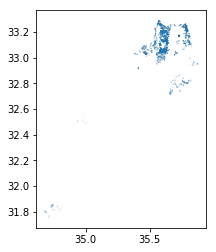

In [23]:
plots.plot()

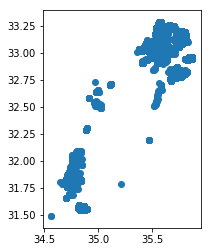

In [25]:
points.plot()

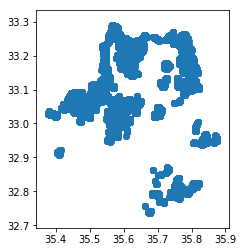

In [26]:
hula_centroids.plot()

In [64]:
hula_centroids['year'] = hula_centroids['date'].dt.year
hula_centroids['month'] = hula_centroids['date'].dt.month
hula_centroids['day'] = hula_centroids['date'].dt.day

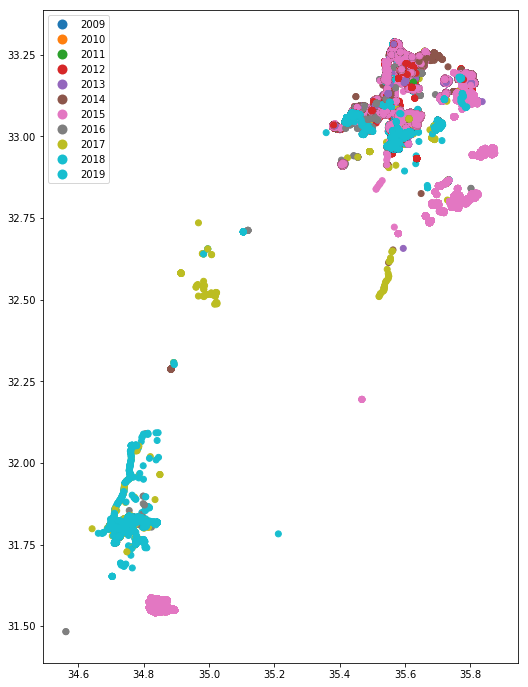

In [52]:
#Categorize by year
f, ax = plt.subplots(1, figsize=(12, 12))
ax = points.plot(ax=ax, column='year', legend=True, categorical=True)
plt.show()

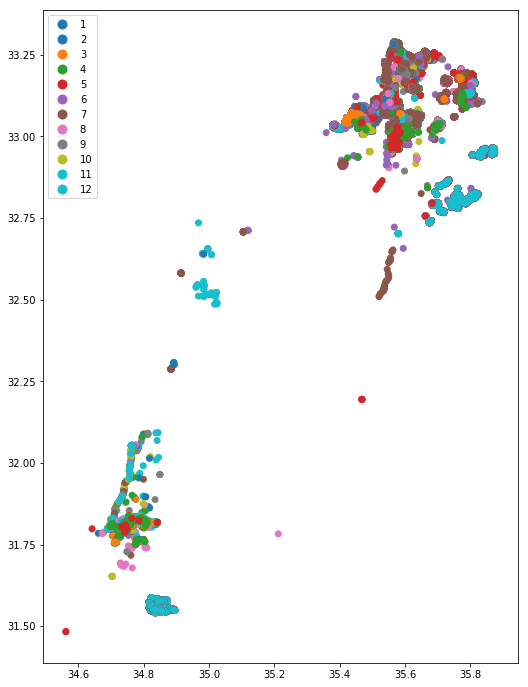

In [53]:
#Categorize by month
f, ax = plt.subplots(1, figsize=(12, 12))
ax = points.plot(ax=ax, column='month', legend=True, categorical=True)
plt.show()